# Principal Component Analysis (PCA)

In [7]:
from datetime import date, timedelta
import matplotlib.pyplot as plt
import numpy as np
from util import util_yahoo_finance as uyf

## The Core Idea

A statistical factor model says that asset returns are driven by a small number of latent factors:

$$r_t = \alpha + Bf_t + \epsilon_t$$

Where:
- $r_t \in \mathbb{R}^N$ — returns on $N$ assets at time $t$
- $B \in \mathbb{R}^{N \times K}$ — **factor loadings** (how sensitive each asset is to each factor)
- $f_t \in \mathbb{R}^K$ — **factor realizations** at time $t$ (the $K$ factors, $K \ll N$)
- $\epsilon_t$ — idiosyncratic returns, assumed uncorrelated across assets

The covariance structure that falls out of this is:

$$\Sigma = B\Sigma_f B^T + D$$

Where $\Sigma_f$ is the factor covariance matrix and $D$ is a diagonal matrix of idiosyncratic variances. This decomposition is the whole point — instead of estimating $\frac{N(N+1)}{2}$ entries in $\Sigma$ directly, you estimate $NK + N$ parameters, which is far smaller when $K \ll N$.

In [70]:
tickers     = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'V', 'PG', 'JNJ', 'XOM', 'BA']
returns     = uyf.get_returns(tickers, start="2025-01-01")
T           = returns.shape[0]
N           = returns.shape[1]
alpha       = np.mean(returns, axis=0)
sigma       = returns.cov().values

## Where PCA Comes In

PCA on the sample covariance matrix $\hat{\Sigma}$ gives you:

$$\hat{\Sigma} = V \Lambda V^T$$

The top $K$ eigenvectors (columns of $V$) become your **factor loadings** $B$, and the factor realizations $f_t$ are the **principal component scores** — the projection of returns onto those eigenvectors.

This is entirely data-driven. No economic interpretation is imposed. The first factor will typically explain the most variance (usually a "market" factor), but you don't know that ahead of time — PCA finds it because it's the direction of maximum variance in the data.

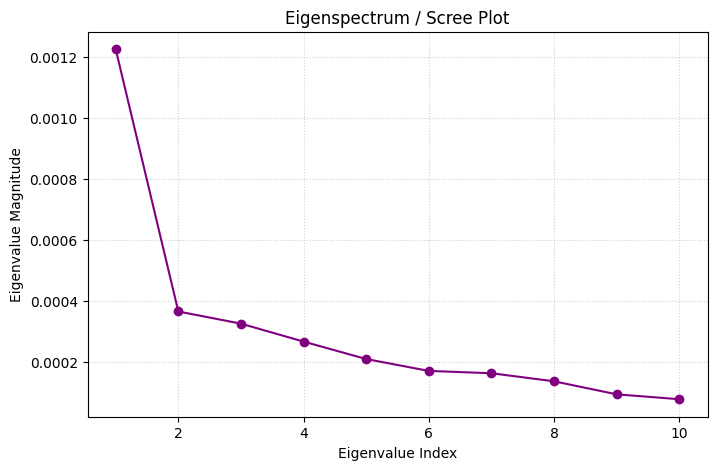

In [71]:
eigenvalues, V = np.linalg.eigh(sigma) # sigma_z = V @ np.diag(eigenvalues) @ V.T
idx            = np.argsort(eigenvalues)[::-1]
eigenvalues    = eigenvalues[idx]
V              = V[:, idx]
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-', color='purple')
plt.title('Eigenspectrum / Scree Plot')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue Magnitude')
plt.grid(True, linestyle=':', alpha=0.6)

## Bai-Ng (2002) — Information Criteria for Factor Selection

The core idea is elegant: treat $K$ as a model selection problem, exactly like AIC/BIC in time series. You're trading off **fit** (more factors explain more variance) against **complexity** (more factors means more parameters to estimate).

The objective for a $K$-factor model fitted to an $N \times T$ return panel is the average residual variance after extracting $K$ factors:

$$V(K) = \frac{1}{NT} \sum_{i=1}^{N} \sum_{t=1}^{T} \hat{\epsilon}_{it}^2(K)$$

This is just the unexplained variance per observation. As you add factors, $V(K)$ falls monotonically. You need a penalty to stop it.

In [75]:
K        = 3 # if K is chosen to be 3
beta     = V[:, :K]
F        = (returns - returns.mean(axis=0)) @ beta
epsilon  = (returns - returns.mean(axis=0)).values - F @ beta.T
V_K      = (epsilon ** 2).values.sum() / N / T


## The Three Criteria

Bai and Ng propose three penalty functions, all of the form:

$$IC(K) = \ln V(K) + K \cdot g(N, T)$$

The penalty $g(N, T)$ differs across the three:

$$PC_1: \quad g(N,T) = \hat{\sigma}^2 \cdot \frac{N + T}{NT} \ln\left(\frac{NT}{N+T}\right)$$

$$PC_2: \quad g(N,T) = \hat{\sigma}^2 \cdot \frac{N + T}{NT} \ln(\min(N,T))$$

$$PC_3: \quad g(N,T) = \hat{\sigma}^2 \cdot \frac{\ln(\min(N,T))}{\min(N,T)}$$

Where $\hat{\sigma}^2 = V(K_{max})$ — the residual variance from a saturated model with $K_{max}$ factors, used to scale the penalty to the same units as $V(K)$.

You pick $\hat{K} = \arg\min_K IC(K)$ for each criterion. In practice, if all three agree, you have high confidence. If they disagree, $PC_3$ is the most conservative (smallest penalty for large panels).

In [ ]:
print(f"{'K':>3}  {'V_K':>10}  {'IC_1':>10}  {'IC_2':>10}  {'IC_3':>10}  {'var_exp':>9}")
print("-" * 60)

for K in range(1, N):
    beta     = V[:, :K]
    F        = (returns - returns.mean(axis=0)) @ beta
    epsilon  = (returns - returns.mean(axis=0)).values - F @ beta.T
    V_K      = (epsilon ** 2).values.sum() / N / T

    IC_K_1   = np.log(V_K) + K * (N + T) / (N * T) * np.log(N * T / (N + T))
    IC_K_2   = np.log(V_K) + K * (N + T) / (N * T) * np.log(min(N, T))
    IC_K_3   = np.log(V_K) + K * np.log(min(N, T)) / min(N, T)
    var_exp  = sum(eigenvalues[:K]) / sum(eigenvalues)
    print(f"{K:>3}  {V_K:>10.4f}  {IC_K_1:>10.4f}  {IC_K_2:>10.4f}  {IC_K_3:>10.4f}  {var_exp:>9.2%}")

  K         V_K        IC_1        IC_2        IC_3    var_exp
------------------------------------------------------------
  1     -8.6215     -8.3877     -8.3849     -8.3913     40.42%
  2     -8.8474     -8.3798     -8.3741     -8.3869     52.47%
  3     -9.1033     -8.4018     -8.3934     -8.4125     63.20%
  4     -9.3762     -8.4409     -8.4297     -8.4552     71.99%
  5     -9.6591     -8.4899     -8.4759     -8.5078     78.89%
  6     -9.9685     -8.5655     -8.5486     -8.5869     84.51%
  7    -10.3935     -8.7567     -8.7371     -8.7817     89.87%
  8    -10.9797     -9.1090     -9.0866     -9.1376     94.36%
  9    -11.7711     -9.6667     -9.6414     -9.6988     97.45%


## The Core Problem: PCA Factors Are Unlabeled

When you run PCA, you get $K$ orthogonal directions of maximum variance. The math hands you loadings $B$ and factor returns $f_t$, but **nothing tells you what they mean**. Unlike a fundamental factor model (where you *impose* "this is the value factor, this is momentum"), PCA discovers structure agnostically. The interpretation is a separate, post-hoc exercise.

Worse, the factors are only identified up to rotation. Recall from the Bai-Ng paper — Theorem 1 establishes convergence only to $H f_t^0$, a *rotation* of the true factors. So even "the true factors" are a basis for a subspace, not unique vectors. Any orthogonal rotation of your $K$ factors spans the same space and fits identically. This matters: it means asking "what is factor 3?" can be ill-posed unless factor 3 happens to be well-separated in variance.

## How Practitioners Actually Interpret PCA Factors

There are four standard techniques, roughly in order of how often they're used:

**1. Read the loadings cross-sectionally.** The first eigenvector $b_1$ almost always has all-positive, roughly-equal entries across assets. That's the **market factor** — everything moves together. You confirm it by correlating $f_{1,t}$ with a market proxy (cap-weighted index return); the correlation is typically 0.95+.

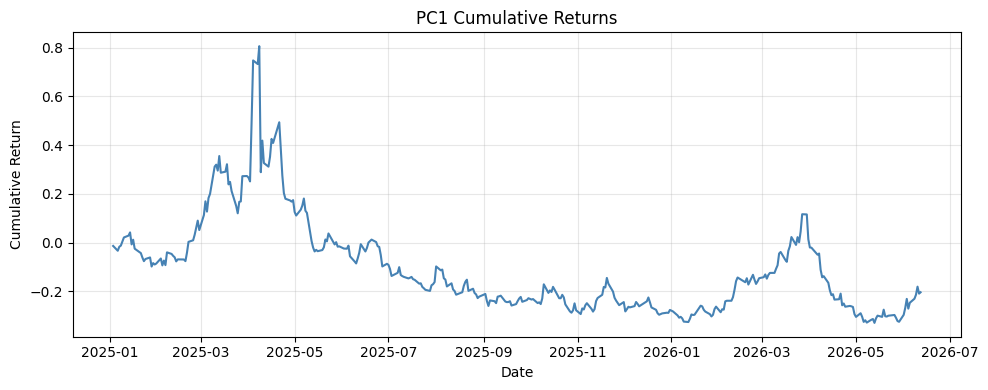

In [82]:
pc1_cumret = (F.iloc[:, 0] + 1).cumprod() - 1

plt.figure(figsize=(10, 4))
plt.plot(pc1_cumret.index, pc1_cumret.values, color="steelblue", lw=1.5)
plt.title("PC1 Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2. Sort loadings by known attributes.** Take the second factor's loadings $b_2$ and sort assets by them. Then look at what sits at the extremes. If the top-loading names are all tech/growth and the bottom are all utilities/value, factor 2 is a growth-vs-value axis. You're essentially doing a cross-sectional regression of loadings on characteristics:
$$b_k = \gamma_0 + \gamma_1 \cdot (\text{sector}) + \gamma_2 \cdot (\text{size}) + \dots + u$$

In [83]:
b2 = V[:, 1]   # second eigenvector = PC2 loadings, one value per asset

sorted_idx = np.argsort(b2)[::-1]
print(f"{'Ticker':>8}  {'PC2 Loading':>12}")
print("-" * 23)
for i in sorted_idx:
    print(f"{tickers[i]:>8}  {b2[i]:>12.6f}")

  Ticker   PC2 Loading
-----------------------
   GOOGL      0.412935
    AMZN      0.331239
    MSFT      0.284612
    AAPL     -0.162659
     JPM     -0.177289
       V     -0.246053
     JNJ     -0.321647
      PG     -0.324445
      BA     -0.388922
     XOM     -0.400435


**3. Correlate factor returns with observable factors.** Regress your statistical $f_{k,t}$ on known factor returns (Fama-French SMB/HML/UMD, sector returns, rates, credit spreads). A high $R^2$ tells you the statistical factor is spanned by named risks. This is the cleanest quantitative bridge between statistical and fundamental factor models.

**4. Rotate toward interpretability.** Since factors are only identified up to rotation, you can deliberately rotate (varimax, or a target rotation toward known factors) to get a more interpretable basis — at the cost of the variance-ordering that PCA gives you.

## The Honest Caveat

In equities, **only the first one or two factors are reliably interpretable.** Factor 1 is the market. Factor 2 is often a recognizable style or sector contrast. Beyond that, the factors are increasingly statistical artifacts — combinations of weak structure and estimation noise, and their composition is unstable across estimation windows. This instability is exactly why the Bai-Ng cutoff matters: factors near the noise boundary may be "significant" but won't carry a stable economic identity.

This is the central tension of statistical factor models for portfolio construction: they're excellent for **risk** (you don't need to name a factor to hedge its variance) but treacherous for **alpha** (you can't take an intentional view on a factor you can't identify).